In [20]:
import operator
from typing import Annotated, Literal, TypedDict

from dotenv import load_dotenv
from langchain.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, StateGraph
from llm_sandbox import SandboxBackend, SandboxSession
from pydantic import BaseModel, Field

load_dotenv()

True

# workflow

In [67]:
evaluator= ChatMistralAI(model='mistral-large-latest')

model= ChatMistralAI(model='mistral-small-latest')

coder= ChatMistralAI(model='codestral-latest')

In [68]:
class Evaluate_Input(BaseModel):
    errors: list[str]= Field(description= 'List summary of all the errors that are present in the code in a single and simple sentence.')
    
class Make_Changes(BaseModel):
    updated_code: str = Field(description='New and updated code solving the errors in the previous code.')
    thought_process: str= Field(description='Detailed thought process of how and why the code was changed to fix the errors.')
    

In [69]:
structured_evaluator= evaluator.with_structured_output(Evaluate_Input)
structured_coder= coder.with_structured_output(Make_Changes)

In [70]:
class FixerState(TypedDict):
    
    user_prompt: str
    current_code: str
    errors: str
    output_current_code: str
    code_history: Annotated[list[str], operator.add]
    error_history: Annotated[list[str], operator.add]
    thought_process_history: Annotated[list[str], operator.add]
    summary: str
    itr: int
    max_itr: int

In [113]:
def evaluate_input(state: FixerState): # model identifies error
    current_code= state['current_code']
    errors= state.get('errors', '')
    itr= state.get('itr', 0)+ 1
    messages= [
        SystemMessage(content="""
        You are a precise static code analyzer.

        Your task is to identify REAL and ACTIONABLE issues in code.

        STRICT RULES:
        1. Only report errors that can be clearly justified from the code or runtime error.
        2. If runtime errors are provided, prioritize explaining their root cause.
        3. Do NOT guess or invent hypothetical issues.
        4. Each error must be independent and non-redundant.
        5. Keep each error to ONE short sentence.

        IMPORTANT:
        - Focus on errors that will cause failure, incorrect output, or broken logic.
        - Ignore minor style issues unless they affect execution.

        OUTPUT:
        Return a list of concise error sentences.
        
        CRITICAL CONSTRAINTS:
        - Do NOT remove functionality to avoid errors
        - Do NOT hardcode expected outputs
        - Do NOT replace logic with placeholders
        
        ENVIRONMENT CONSTRAINT:
        The code is executed in a restricted sandbox where some modules may not be installed.

        If you see errors like:
        - ModuleNotFoundError
        - ImportError

        Then:
        1. Treat them as environment issues, NOT code bugs
        2. Do NOT suggest removing or replacing imports
        3. Clearly state that the import is valid but unavailable in the environment"""),
        
        HumanMessage(content=f"""
        User intent:
        {state['user_prompt']}

        Code:
        {current_code}

        Runtime error (if any):
        {errors}

        IMPORTANT CONTEXT:
        - The execution environment may NOT have all Python modules installed
        - Import-related errors may NOT indicate a problem in the code
        
        Task:
        List ALL real issues in the code.

        Guidelines:
        - If runtime error exists → explain its cause
        - If code runs but is logically incorrect → include logic errors
        - Avoid vague statements like "code may fail"
        - Be specific and technical

        Special handling:
        - If error is ModuleNotFoundError → mark it as environment limitation
        - Do NOT treat it as a bug in user code""")
    ]
    
    response= structured_evaluator.invoke(messages)
    
    return {'current_code': current_code, 'errors': response.errors, 'error_history': [response.errors], 'code_history': [current_code], 'itr': itr}
    
def make_changes(state: FixerState): # model generates updated code
    
    current_code= state['current_code']
    
    messages= [
        SystemMessage(content="""
        You are a precise code repair system.

        Your job is to FIX code using the provided error list.

        STRICT RULES:
        1. Fix ONLY the reported errors unless a directly related issue is obvious.
        2. Preserve original logic and structure as much as possible.
        3. Do NOT rewrite the entire code unless absolutely necessary.
        4. Do NOT hardcode outputs or bypass logic.
        5. Do NOT suppress errors using try/except unless required.
        6. Ensure the code remains clean, minimal, and readable.
        7. The final code MUST be executable.

        THOUGHT PROCESS RULES:
        - Explain fixes briefly and clearly
        - Focus only on what was changed and why
        - Avoid unnecessary verbosity

        OUTPUT:
        - Provide full updated code
        - Provide concise reasoning for each fix
        
        CRITICAL CONSTRAINTS:
        - Do NOT remove functionality to avoid errors
        - Do NOT hardcode expected outputs
        - Do NOT replace logic with placeholders
        
        ENVIRONMENT RULE:
        If an error is caused by missing modules (ModuleNotFoundError / ImportError):

        - DO NOT remove the import
        - DO NOT replace the library
        - ASSUME the module exists in the user's environment
        - Leave the import unchanged

        Only fix actual code issues, not environment limitations."""),
        
        HumanMessage(content=f"""
        User intent:
        {state['user_prompt']}

        Current code:
        {current_code}

        Detected errors:
        {state['errors']}

        Task:
        Fix the code so that:
        1. It runs without errors
        2. It correctly follows the user intent
        3. Fix only real code issues.
        4. Do NOT modify imports unless they are syntactically incorrect.

        Guidelines:
        - Apply minimal and targeted fixes
        - Maintain original functionality
        - Do not introduce new features unless required to fix errors
        - Ensure the code is logically correct, not just executable

        Important:
        - Do NOT remove functionality to avoid errors
        - Do NOT replace logic with placeholders
        - Some errors may be due to missing modules in the sandbox
        - Assume all imports are valid in the user's real environment""")
    ]
    
    response= structured_coder.invoke(messages)
    
    return {'current_code': response.updated_code, 'thought_process_history': [response.thought_process]}
    
def evaluate_changes(state: FixerState): # the suggested code is run and evaluated
    
    current_code= state['current_code']
    
    session = SandboxSession(
    backend=SandboxBackend.DOCKER,
    lang="python",
    keep_template=True
    )
    
    session.open()
    
    result= session.run(current_code)
    
    session.close()
    
    output= {
        'stdout': result.stdout,
        'stderr': result.stderr,
        'exit_code': result.exit_code
    }
    
    return {'output_current_code': output, 'errors': result.stderr}
    
def provide_summary(state: FixerState): # the final output based on thought process
    
    messages=[
        SystemMessage(content="""
        You are a technical summarizer.

        Summarize how the code was fixed.

        RULES:
        - Be concise and clear
        - Focus only on important fixes
        - Do not include unnecessary details"""),
        
        HumanMessage(content=f"""
        User request:
        {state['user_prompt']}

        Final code:
        {state['current_code']}

        Errors encountered:
        {state['error_history']}

        Fixes applied:
        {state['thought_process_history']}

        Task:
        Summarize:
        1. Main issues in original code
        2. Key fixes applied
        3. Why final code works""")
    ]
    
    response= model.invoke(messages)
    
    return {'summary': response.content}

def provide_failure_summary(state: FixerState): # the final output if the error could not be solved
    
    messages=[
        SystemMessage(content="""
        You are a debugging assistant.

        Summarize why the system failed to fix the code.

        Be precise and actionable."""),
        
        HumanMessage(content=f"""
        User request:
        {state['user_prompt']}

        Final attempted code:
        {state['current_code']}

        Error history:
        {state['error_history']}

        Fix attempts:
        {state['thought_process_history']}

        Task:
        1. Explain why the fixes failed
        2. Identify what information is missing
        3. Ask one clear follow-up question to the user""")
    ]
    
    response= model.invoke(messages)
    
    return {'summary': response.content}

def check_condition(state: FixerState):
    output = state['output_current_code']
    itr= state['itr']
    max_itr= state['max_itr'] 
    
    if itr >= max_itr:
        return 'stop_trying'
    elif output['exit_code'] != 0:
        return 'retry'
    else:
        return 'done'

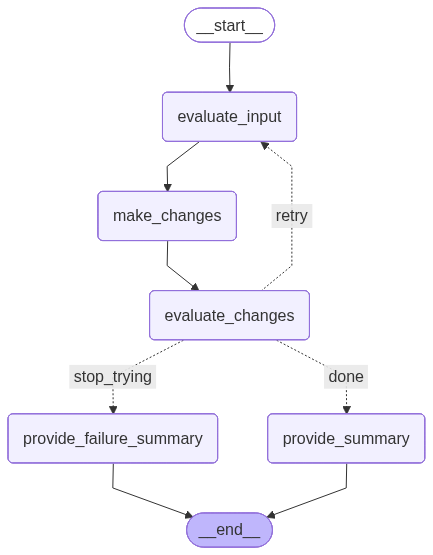

In [114]:
graph = StateGraph(FixerState)

graph.add_node('evaluate_input', evaluate_input)
graph.add_node('make_changes', make_changes)
graph.add_node('evaluate_changes', evaluate_changes)
graph.add_node('provide_summary', provide_summary)
graph.add_node('provide_failure_summary', provide_failure_summary)

graph.add_edge(START, 'evaluate_input')
graph.add_edge('evaluate_input', 'make_changes')
graph.add_edge('make_changes', 'evaluate_changes')

graph.add_conditional_edges(
    'evaluate_changes',
    check_condition,
    {
        'retry': 'evaluate_input',
        'stop_trying': 'provide_failure_summary',
        'done': 'provide_summary'
    }
)

graph.add_edge('provide_summary', END)
graph.add_edge('provide_failure_summary', END)

chatbot= graph.compile()
chatbot

In [118]:
code= """ 
# Complex system: expression evaluator + graph algorithms + VM + data pipeline

############################
# Expression Engine
############################

class Lexer:
    def __init__(self, text):
        self.text = text
        self.pos = 0

    def next_token(self):
        while self.pos < len(self.text) and self.text[self.pos] == " ":
            self.pos += 1

        if self.pos >= len(self.text):
            return None

        ch = self.text[self.pos]

        if ch.isdigit():
            num = 0
            while self.pos < len(self.text) and self.text[self.pos].isdigit():
                num = num * 10 + int(self.text[self.pos])
                self.pos += 1
            return ("INT", num)

        self.pos += 1
        return (ch, ch)


class Parser:
    def __init__(self, lexer):
        self.lexer = lexer
        self.current = self.lexer.next_token()

    def eat(self, typ):
        if self.current and self.current[0] == typ:
            self.current = self.lexer.next_token()
        else:
            raise Exception("Syntax error")

    def factor(self):
        tok = self.current
        if tok[0] == "INT":
            self.eat("INT")
            return tok[1]
        elif tok[0] == "(":
            self.eat("(")
            val = self.expr()
            self.eat(")")
            return val

    def term(self):
        result = self.factor()
        while self.current and self.current[0] in ("*", "/"):
            op = self.current[0]
            self.eat(op)
            if op == "*":
                result *= self.factor()
            else:
                result //= self.factor()
        return result

    def expr(self):
        result = self.term()
        while self.current and self.current[0] in ("+", "-"):
            op = self.current[0]
            self.eat(op)
            if op == "+":
                result += self.term()
            else:
                result -= self.term()
        return result


############################
# Graph Algorithms
############################

class Graph:
    def __init__(self):
        self.edges = {}

    def add_edge(self, u, v):
        self.edges.setdefault(u, []).append(v)
        self.edges.setdefault(v, []).append(u)

    def bfs(self, start):
        visited = set()
        queue = [start]
        order = []

        while queue:
            node = queue.pop(0)
            if node in visited:
                continue
            visited.add(node)
            order.append(node)
            for n in self.edges.get(node, []):
                queue.append(n)
        return order

    def shortest_path(self, start, end):
        queue = [(start, [start])]
        visited = set()

        while queue:
            node, path = queue.pop(0)
            if node == end:
                return path
            if node in visited:
                continue
            visited.add(node)
            for n in self.edges.get(node, []):
                queue.append((n, path + [n]))
        return None


############################
# Stack-based Virtual Machine
############################

class VirtualMachine:
    def __init__(self):
        self.stack = []
        self.memory = {}

    def run(self, program):
        ip = 0
        while ip < len(program):
            instr = program[ip]
            op = instr[0]

            if op == "PUSH":
                self.stack.append(instr[1])

            elif op == "ADD":
                a = self.stack.pop()
                b = self.stack.pop()
                self.stack.append(a + b)

            elif op == "SUB":
                a = self.stack.pop()
                b = self.stack.pop()
                self.stack.append(a - b)

            elif op == "MUL":
                a = self.stack.pop()
                b = self.stack.pop()
                self.stack.append(a * b)

            elif op == "STORE":
                self.memory[instr[1]] = self.stack.pop()

            elif op == "LOAD":
                self.stack.append(self.memory.get(instr[1], 0))

            elif op == "JMP":
                ip = instr[1]
                continue

            elif op == "JZ":
                val = self.stack.pop()
                if val == 0:
                    ip = instr[1]
                    continue

            elif op == "PRINT":
                print(self.stack[-1])

            ip += 1


############################
# Data Pipeline (Generators)
############################

def stream_numbers(n):
    for i in range(n):
        yield i


def filter_even(stream):
    for x in stream:
        if x % 2 == 0:
            yield x


def square(stream):
    for x in stream:
        yield x * x


def take(stream, k):
    result = []
    for i, val in enumerate(stream):
        if i > k:
            break
        result.append(val)
    return result


############################
# Tree Structure
############################

class Node:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None


def inorder(root):
    if root is None:
        return []
    return inorder(root.left) + [root.val] + inorder(root.right)


############################
# Demo
############################

if __name__ == "__main__":
    # Expression
    parser = Parser(Lexer("10 + 2 * 3"))
    print("Expr:", parser.expr())

    # Graph
    g = Graph()
    g.add_edge(1, 2)
    g.add_edge(2, 3)
    print("BFS:", g.bfs(1))
    print("Path:", g.shortest_path(1, 3))

    # VM
    vm = VirtualMachine()
    program = [
        ("PUSH", 4),
        ("PUSH", 5),
        ("ADD",),
        ("STORE", "x"),
        ("LOAD", "x"),
        ("PRINT",)
    ]
    vm.run(program)

    # Pipeline
    data = stream_numbers(10)
    data = filter_even(data)
    data = square(data)
    print("Pipeline:", take(data, 3))

    # Tree
    root = Node(2)
    root.left = Node(1)
    root.right = Node(3)
    print("Tree:", inorder(root))
"""

In [119]:
initial_state= {
    'user_prompt': "Why is there no output?",
    'current_code': f"""{code}""",
    'max_itr': 3,
}

final_state= chatbot.invoke(initial_state)
final_state

{'user_prompt': 'Why is there no output?',
 'current_code': '# Complex system: expression evaluator + graph algorithms + VM + data pipeline\r\n\r\n############################\r\n# Expression Engine\r\n############################\r\n\r\nclass Lexer:\r\n    def __init__(self, text):\r\n        self.text = text\r\n        self.pos = 0\r\n\r\n    def next_token(self):\r\n        while self.pos < len(self.text) and self.text[self.pos] == " ":\r\n            self.pos += 1\r\n\r\n        if self.pos >= len(self.text):\r\n            return None\r\n\r\n        ch = self.text[self.pos]\r\n\r\n        if ch.isdigit():\r\n            num = 0\r\n            while self.pos < len(self.text) and self.text[self.pos].isdigit():\r\n                num = num * 10 + int(self.text[self.pos])\r\n                self.pos += 1\r\n            return ("INT", num)\r\n\r\n        self.pos += 1\r\n        return (ch, ch)\r\n\r\n\r\nclass Parser:\r\n    def __init__(self, lexer):\r\n        self.lexer = lexer\r\n

In [120]:
print(final_state['summary'])

### **Summary of Code Fixes**

#### **1. Main Issues in Original Code**
- **`take` function**: Incorrectly broke loop at `i > k`, returning an extra element.
- **`VirtualMachine` class**: No stack underflow checks for arithmetic/logic operations.
- **`Parser` class**: Used generic `Exception` for syntax errors (poor debugging).
- **Input validation**: Missing checks for `program` in `VirtualMachine`.
- **`Graph.shortest_path`**: No handling for missing `start`/`end` nodes.

#### **2. Key Fixes Applied**
- Fixed `take` to break at `i >= k`.
- Added stack underflow checks in `VirtualMachine` (e.g., `ADD`, `SUB`, `MUL`).
- Replaced generic `Exception` with `SyntaxError` in `Parser`.
- Added input validation in `VirtualMachine`.
- Added checks in `Graph.shortest_path` for missing nodes.

#### **3. Why Final Code Works**
- Prevents crashes (stack underflow, invalid inputs).
- Ensures correct data pipeline behavior.
- Improves error clarity and debugging.
- Handles edge cases (missing graph 

# Sandbox check

In [ ]:
session = SandboxSession(
    backend=SandboxBackend.DOCKER,
    lang="python",
    keep_template=True
)

codes = """
from langchain.messages import SystemMessage


def llm_call(state: dict):

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }"""

session.open()


result = session.run(codes)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("EXIT CODE:", result.exit_code)

session.close()

STDOUT: 
STDERR: Traceback (most recent call last):
  File "/sandbox/be33db63248a44f5b238e57b977bac4a.py", line 2, in <module>
    from langchain.messages import SystemMessage
ModuleNotFoundError: No module named 'langchain'

EXIT CODE: 1


In [128]:
from langchain.agents import create_agent

agent= create_agent(
    model= ChatMistralAI(model='codestral-latest'),
)

In [130]:
result= agent.invoke({
    'messages':[HumanMessage(content='write a python code to perform 4+5. Only provide code nothing else.')]
})
print(result['messages'][-1].content)

```python
print(4 + 5)
```


In [ ]:
from langchain_core.tools import tool
from langchain_mistralai import ChatMistralAI


@tool
def execute_code(code: str) -> str:
    """Execute Python code and return the output."""
    return "stdout: 9\nstderr: \nexit_code: 0"  # fake for testing

model = ChatMistralAI(model="codestral-latest")
model_with_tools = model.bind_tools([execute_code])

response = model_with_tools.invoke("Run print(4+5) for me")
print(response.tool_calls)  # Does this return anything?

[{'name': 'execute_code', 'args': {'code': 'print(4 + 5)'}, 'id': 'i1w2upwTv', 'type': 'tool_call'}]


In [132]:
print(response)

content="Sure, I'll execute the code for you." additional_kwargs={'tool_calls': [{'id': 'i1w2upwTv', 'function': {'name': 'execute_code', 'arguments': '{"code": "print(4 + 5)"}'}, 'index': 0}]} response_metadata={'token_usage': {'prompt_tokens': 72, 'total_tokens': 99, 'completion_tokens': 27, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'codestral-latest', 'model': 'codestral-latest', 'finish_reason': 'tool_calls', 'model_provider': 'mistralai'} id='lc_run--019d2e90-5c72-7590-924f-cc453305f60a-0' tool_calls=[{'name': 'execute_code', 'args': {'code': 'print(4 + 5)'}, 'id': 'i1w2upwTv', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 72, 'output_tokens': 27, 'total_tokens': 99}
